# 3. Machine learning - split by date

This notebook corresponds to the second part of the project. This part uses machine learning, a data-driven approach to model $[OH]$ without knowledge of its chemistry. Regression methods are used as $[OH]$ is a label that has continuous values.

In order to evaluate the performance of machine learning methods they are usually trained on a subset of data and tested on the remaining subset, and requires a choice to be made about how the dataset is split into train/test sets. This notebook explores a common approach to timeseries data, train/test split by date. Here, the last 2 days are used as test data.

The other notebook `4. Machine learning - random split` looks at another approach, splitting the whole dataset randomly using K-fold cross-validation.

The following regression methods are used:
- Linear regression
- Ridge regression
- Random forest
- Gradient boosting

Each method in turn is fit on the train and test data, and the predictions on the test data are plotted alongside the predictions from the chemical box model (minimal input) and ATom measurements.

There are two sets of features being used:

1. The minimal set of features for the first box model. These are `Temp, Pres, jO3_O2_O1D_CAFS, O3_M, H2O_M, CO_M, CH4_M`
2. These features plus the feature `HO2`. $OH$ and $HO_2$ are linked through interconversion reactions so the purpose of this is to evaluate if predictions are more accurate and hence if model score is improved.

The machine learning predictions will be visualised along with the box model predictions, to save re-calculating $[OH]$ multiple times the box model output is read in as a pre-processed `box_model_output.csv` file.

Random forest and gradient boosting also have an additional attribute called feature importance and the plots for this are shown too.

---

In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import pytz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import matplotlib as mpl

In [4]:
df = pd.read_csv("box_model_output.csv")
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['date'] = df['UTC_Start_dt']

In [5]:
scaler = StandardScaler()

df_inputs = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M']]
df_inputs_HO2 = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M', 'HO2_ATHOS']]

X = df_inputs
X_HO2 = df_inputs_HO2
y = df["[OH]_measured"]

X_train = df_inputs[df["date"] < "2016-08-22"]
X_train_normalised = scaler.fit_transform(X_train)

X_train_HO2 = df_inputs_HO2[df["date"] < "2016-08-22"]
X_train_normalised_HO2 = scaler.fit_transform(X_train_HO2)

y_train = df[["[OH]_measured"]][df["date"] < "2016-08-22"]
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-22")]
X_test_normalised = scaler.fit_transform(X_test)

X_test_HO2 = df_inputs_HO2[(df["date"] > "2016-08-22")]
X_test_normalised_HO2 = scaler.fit_transform(X_test_HO2)

y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-22")]

In [6]:
# Creates a list of indexes for the date of 22/08/2016 for easier plotting later
indexes = df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")].count()

### Linear regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

LinearRegression fits a linear model with coefficients $w = (w_1, …, w_p)$ where $p$ is the number of features to minimise the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation.

Model score on training data: 0.491
Model score on testing data: 0.342
===
WITH HO2 IN FEATURES
Model score on training data: 0.573
Model score on testing data: 0.492


Text(0.5, 1.0, '23/08/2016')

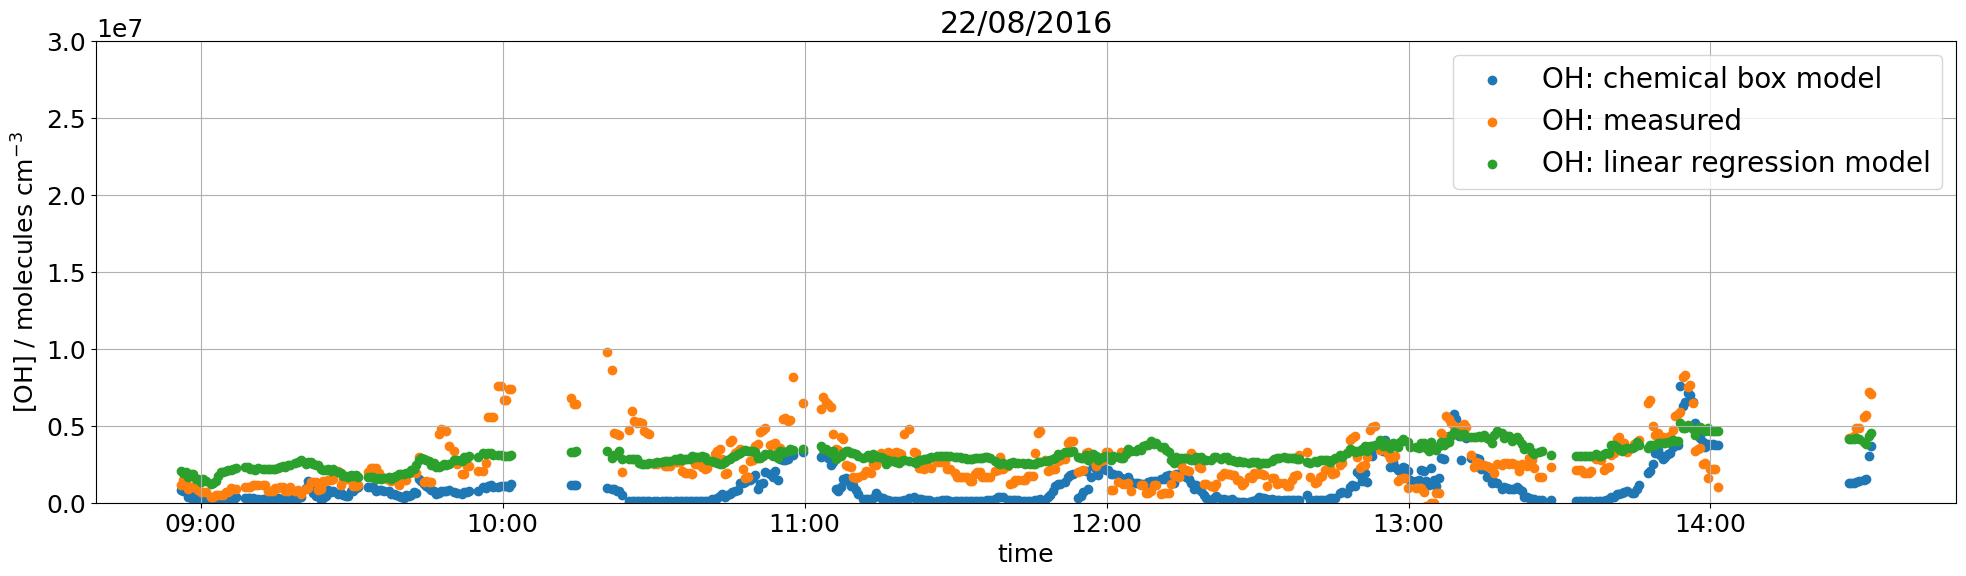

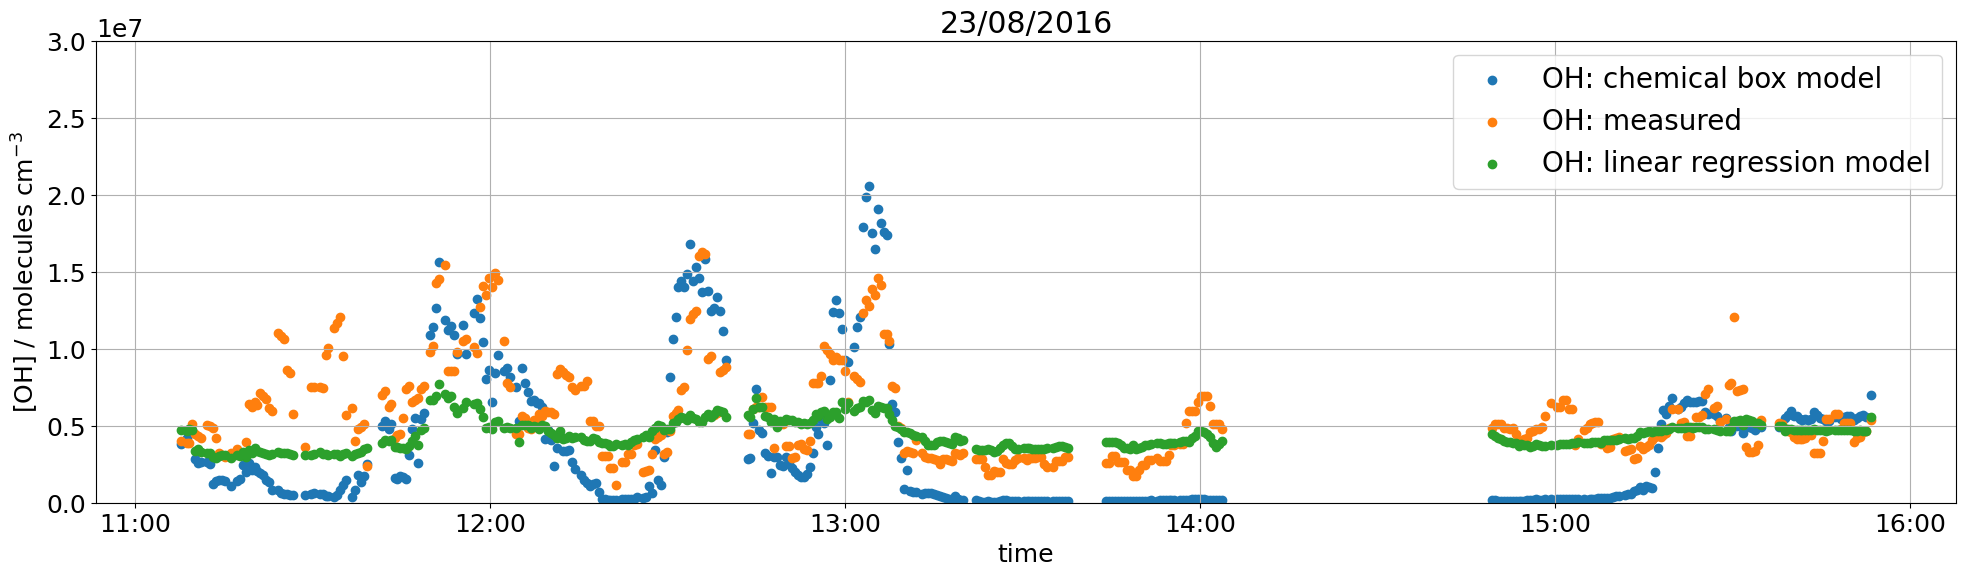

In [8]:
reg = LinearRegression().fit(X_train, y_train)
pred_reg = reg.predict(X_test)

reg_HO2 = LinearRegression().fit(X_train_HO2, y_train)
pred_reg_HO2 = reg_HO2.predict(X_test_HO2)

print(f"Model score on training data: {round(reg.score(X_train, y_train), 3)}")
print(f"Model score on testing data: {round(reg.score(X_test, y_test), 3)}")

print("===")
print("WITH HO2 IN FEATURES")

print(f"Model score on training data: {round(reg_HO2.score(X_train_HO2, y_train), 3)}")
print(f"Model score on testing data: {round(reg_HO2.score(X_test_HO2, y_test), 3)}")

mpl.rcParams["font.size"] = 18

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_reg[0:indexes], label="OH: linear regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("22/08/2016")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_reg[indexes:], label="OH: linear regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("23/08/2016")

Similar to box model, can take $r^2$ scores at different altitudes to assess if there may be a trend between altitude and model fit

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


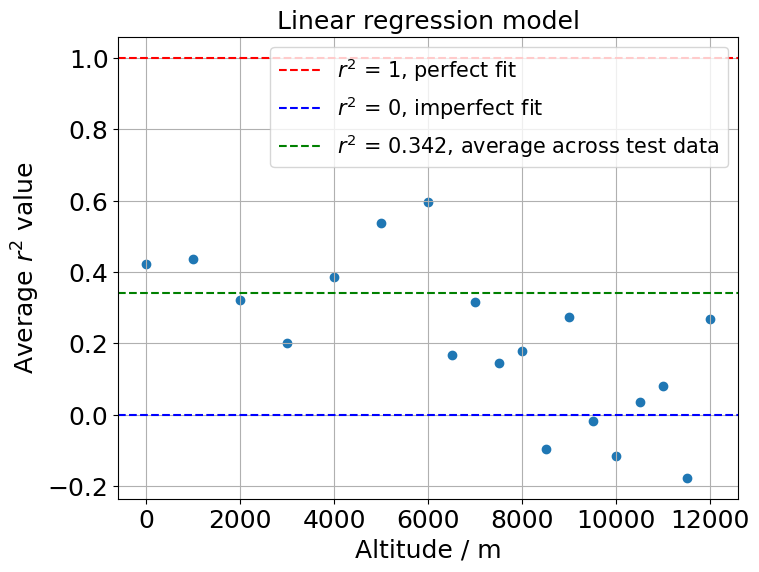

In [9]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    X = X_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(reg.score(X, y))

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (reg.score(X_test, y_test)), color='g', linestyle='--', label=f'$r^2$ = {round(reg.score(X_test, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("Linear regression model")
plt.legend(prop={'size':15})

plt.grid()

In [10]:
print(f"RMSE: {sklearn.metrics.root_mean_squared_error(y_test, pred_reg):.2e}")
print(f"RMSE with HO2: {sklearn.metrics.root_mean_squared_error(y_test, pred_reg_HO2):.2e}")

RMSE: 2.27e+06
RMSE with HO2: 1.99e+06


### Ridge regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

Ridge regression is an example of a regularisation procedure, which is an extension of the linear model. As well as minimising the mean squared error, it also penalises large coefficient values.

Used when there is collinearity in input values and ordinary least squares would overfit training data.

Model score on training data: 0.491
Model score on testing data:  0.214
===
WITH HO2 IN FEATURES
Model score on training data: 0.573
Model score on testing data: 0.313


Text(0.5, 1.0, '23/08/2016')

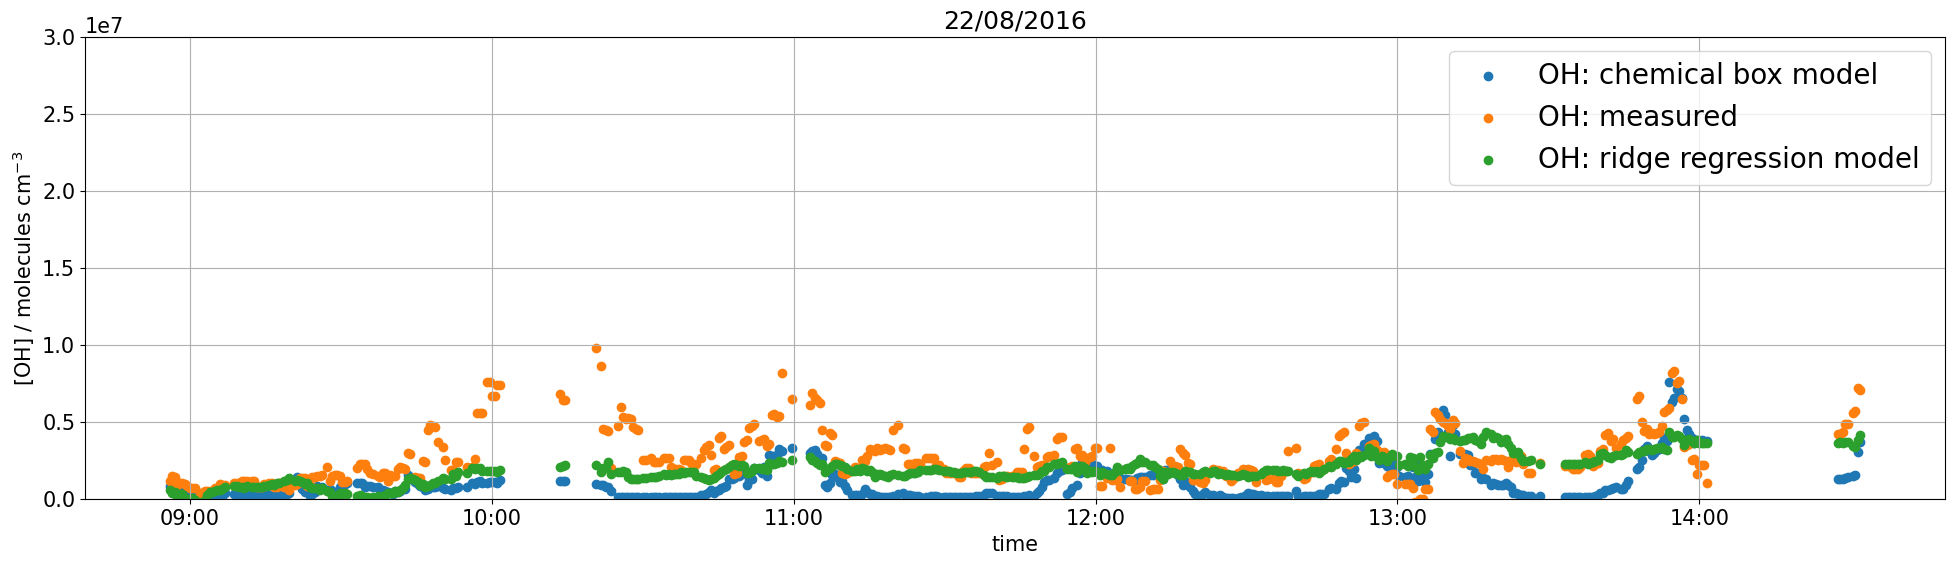

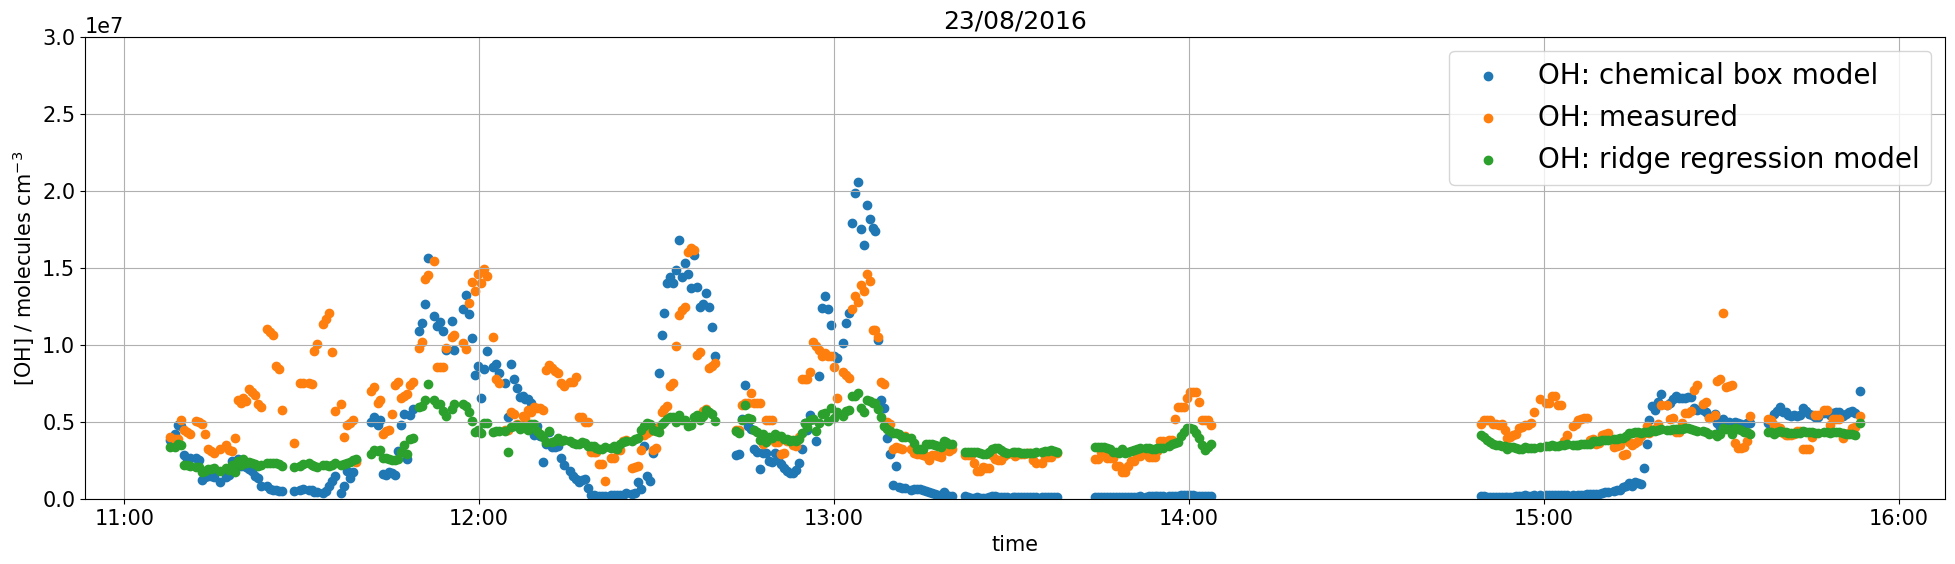

In [12]:
X_train_normalised = scaler.fit_transform(X_train)
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-22")]
X_test_normalised = scaler.fit_transform(X_test)

ridgereg = Ridge(random_state=42)
ridgereg.fit(X_train_normalised, y_train)

pred_ridgereg = ridgereg.predict(X_test_normalised)

ridgereg_HO2 = Ridge(random_state=42)
ridgereg_HO2.fit(X_train_normalised_HO2, y_train)

pred_ridgereg_HO2 = ridgereg_HO2.predict(X_test_normalised_HO2)

print(f"Model score on training data: {round(ridgereg.score(X_train_normalised, y_train), 3)}")
print(f"Model score on testing data:  {round(ridgereg.score(X_test_normalised, y_test), 3)}")

print("===")
print("WITH HO2 IN FEATURES")

print(f"Model score on training data: {round(ridgereg_HO2.score(X_train_normalised_HO2, y_train), 3)}")
print(f"Model score on testing data: {round(ridgereg_HO2.score(X_test_normalised_HO2, y_test), 3)}")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_ridgereg[0:indexes], label="OH: ridge regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("22/08/2016")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label = "OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label = "OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_ridgereg[indexes:], label = "OH: ridge regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("23/08/2016")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


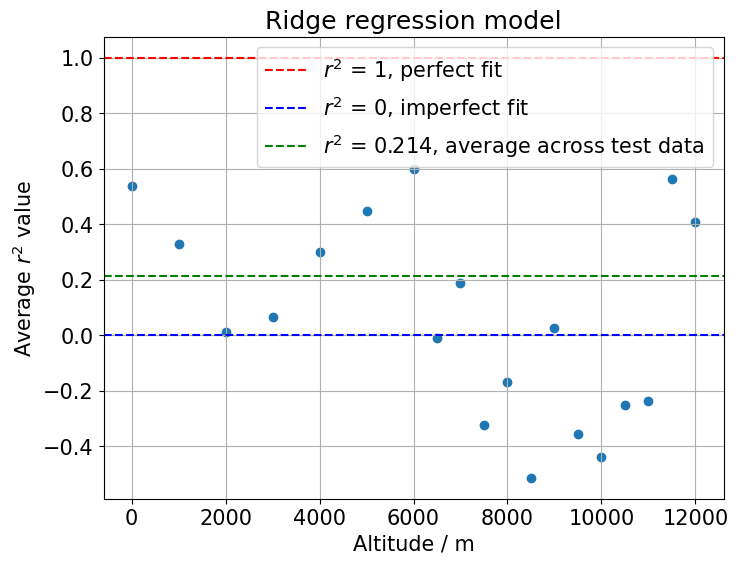

In [13]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    X = X_test_normalised[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(ridgereg.score(X, y))

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (ridgereg.score(X_test_normalised, y_test)), color='g', linestyle='--', label=f'$r^2$ = {round(ridgereg.score(X_test_normalised, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("Ridge regression model")
plt.legend(prop={'size':15})

plt.grid()

In [14]:
print(f"RMSE: {sklearn.metrics.root_mean_squared_error(y_test, pred_ridgereg):.2e}")
print(f"RMSE with HO2: {sklearn.metrics.root_mean_squared_error(y_test, pred_ridgereg_HO2):.2e}")

RMSE: 2.48e+06
RMSE with HO2: 2.32e+06


### Random forest
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Random forest fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

C:\Users\Sophie\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Sophie\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model score on training data: 0.965
Model score on testing data: 0.295
===
WITH HO2 IN FEATURES
Model score on training data: 0.97
Model score on testing data: 0.422


Text(0.5, 1.0, '23/08/2016')

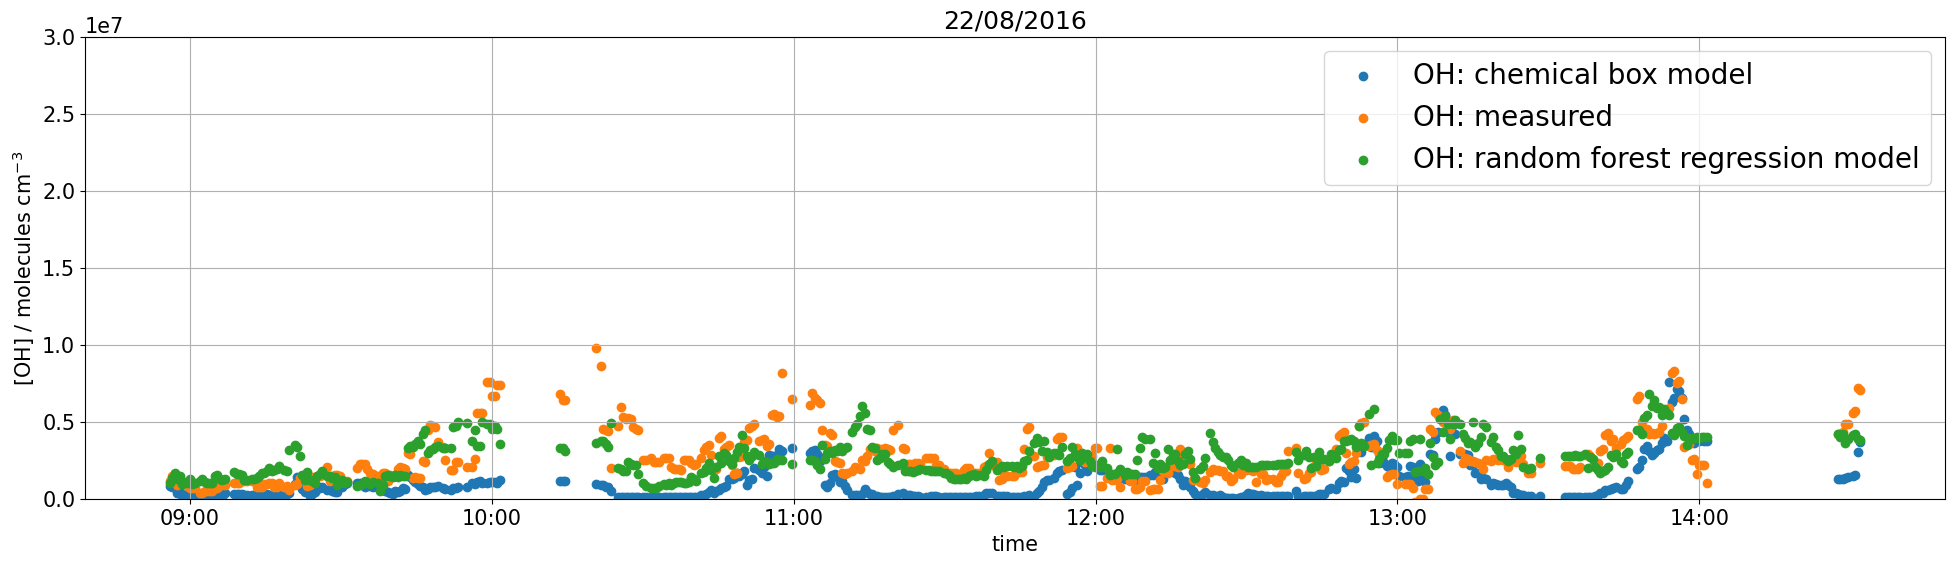

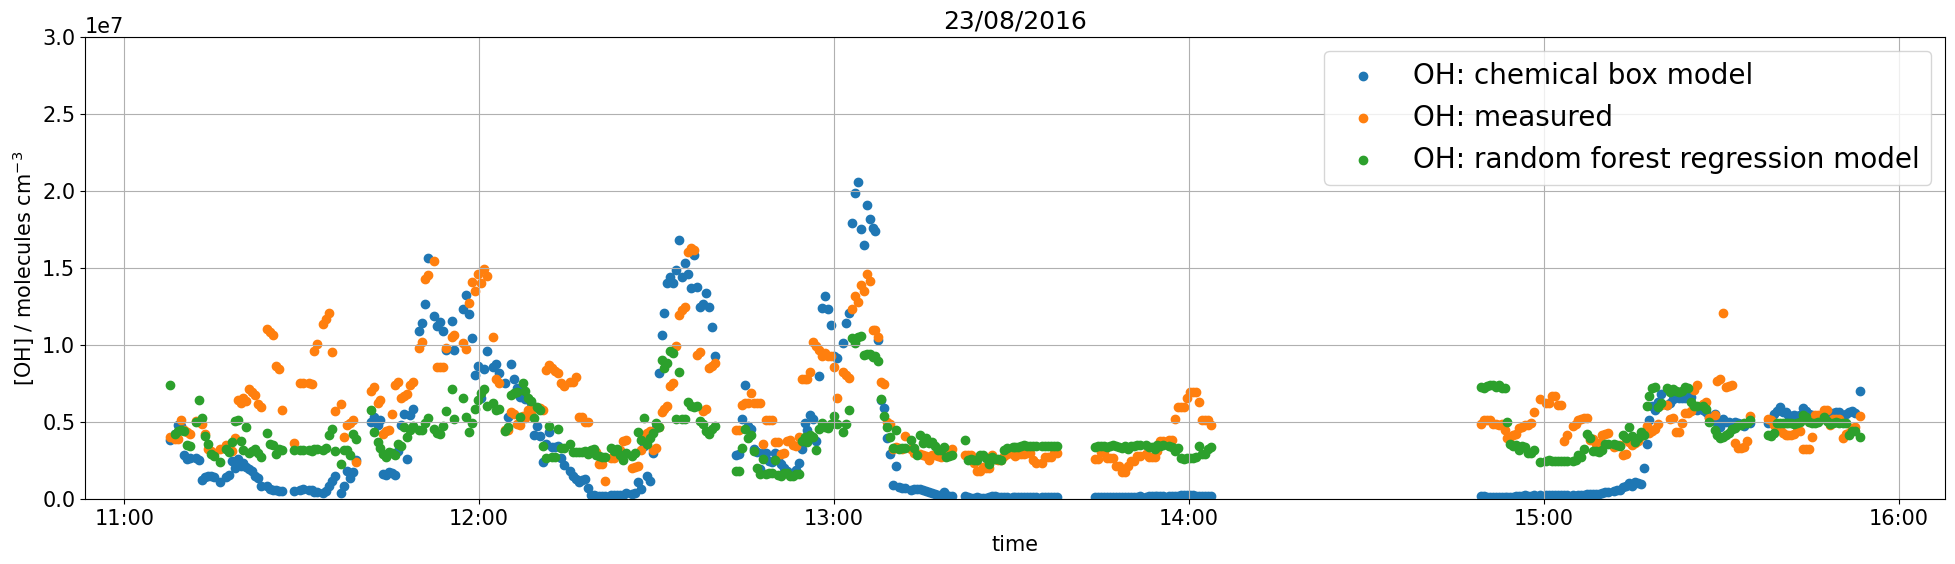

In [16]:
rfreg = RandomForestRegressor(random_state=42)
rfreg.fit(X_train, y_train)

pred_rfreg = rfreg.predict(X_test)

rfreg_HO2 = RandomForestRegressor(random_state=42)
rfreg_HO2.fit(X_train_HO2, y_train)

pred_rfreg_HO2 = rfreg_HO2.predict(X_test_HO2)

print(f"Model score on training data: {round(rfreg.score(X_train, y_train), 3)}")
print(f"Model score on testing data: {round(rfreg.score(X_test, y_test), 3)}")

print("===")
print("WITH HO2 IN FEATURES")

print(f"Model score on training data: {round(rfreg_HO2.score(X_train_HO2, y_train), 3)}")
print(f"Model score on testing data: {round(rfreg_HO2.score(X_test_HO2, y_test), 3)}")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_rfreg[0:indexes], label="OH: random forest regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("22/08/2016")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_rfreg[indexes:], label="OH: random forest regression model")
ax1.legend(prop={'size':20})


plt.ylim(0, 3e7)
plt.grid()
plt.title("23/08/2016")

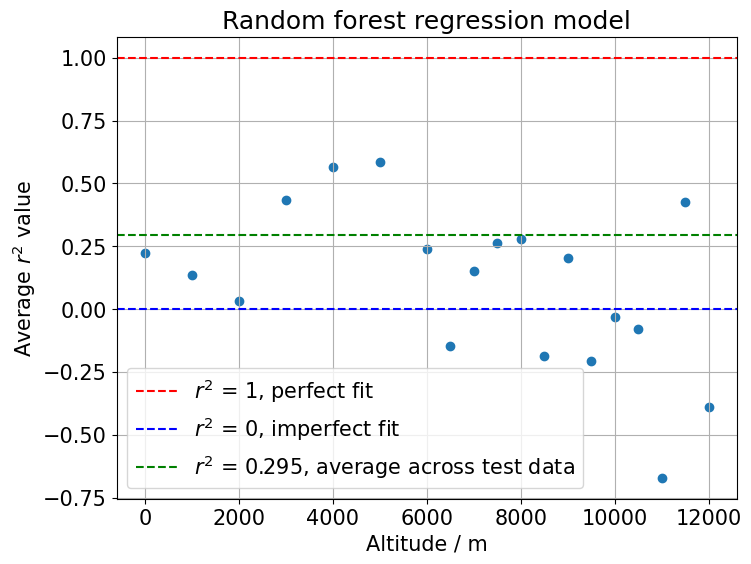

In [17]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
for i in range(len(numbers) - 1):
    X = X_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(rfreg.score(X, y))

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (rfreg.score(X_test, y_test)), color='g', linestyle='--', label=f'$r^2$ = {round(rfreg.score(X_test, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("Random forest regression model")
plt.legend(prop={'size':15})

plt.grid()

In [18]:
print(f"RMSE: {sklearn.metrics.root_mean_squared_error(y_test, pred_rfreg):.2e}")
print(f"RMSE with HO2: {sklearn.metrics.root_mean_squared_error(y_test, pred_rfreg_HO2):.2e}")

RMSE: 2.35e+06
RMSE with HO2: 2.13e+06


### Feature importance with random forest

Text(0.5, 1.0, 'Random forest regression model')

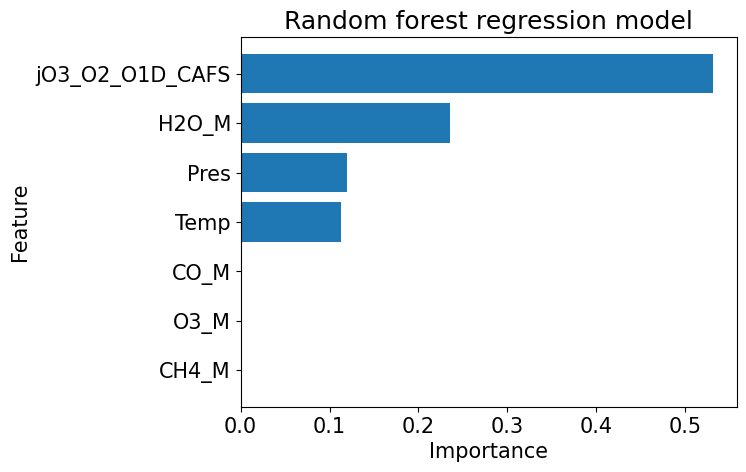

In [20]:
importances = rfreg.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random forest regression model")

Results are as expected - the production of $OH$ depends strongly on the reaction between $O(^1D)$ and $H_2O$ and this process requires UV from sunlight.

Note: when running this code on the JASMIN notebook environment, the graph appeared different and this is what was used in the report:
![random_forest_feature_importance_jasmin](random_forest_feature_importance_jasmin.png)

### Gradient boosting
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html

This algorithm builds an additive model in a forward stage-wise fashion. It produces a predictive model from an ensemble of weak predictive models

C:\Users\Sophie\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
C:\Users\Sophie\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Model score on training data: 0.824
Model score on testing data: 0.261
===
WITH HO2 IN FEATURES
Model score on training data: 0.834
Model score on testing data: 0.383


Text(0.5, 1.0, '23/08/2016')

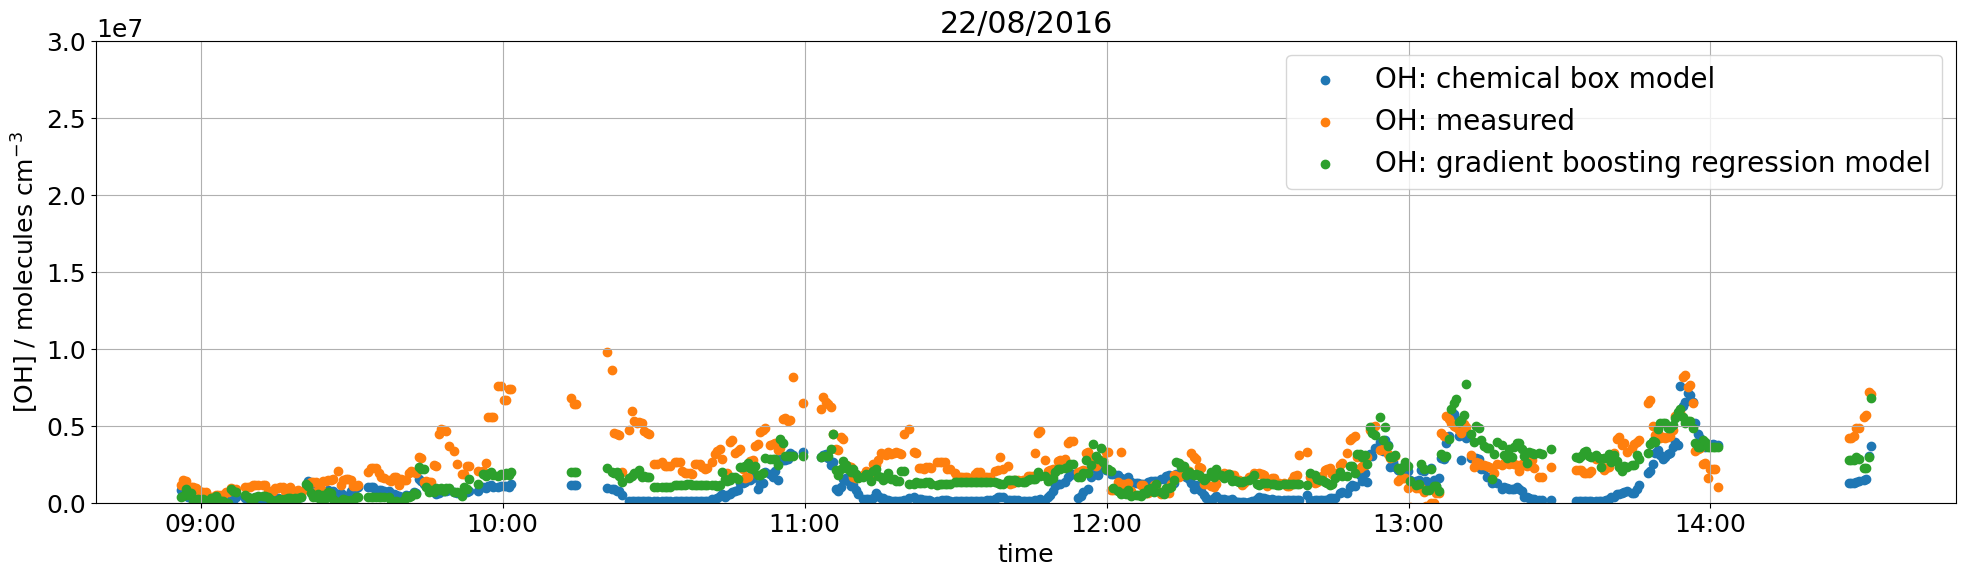

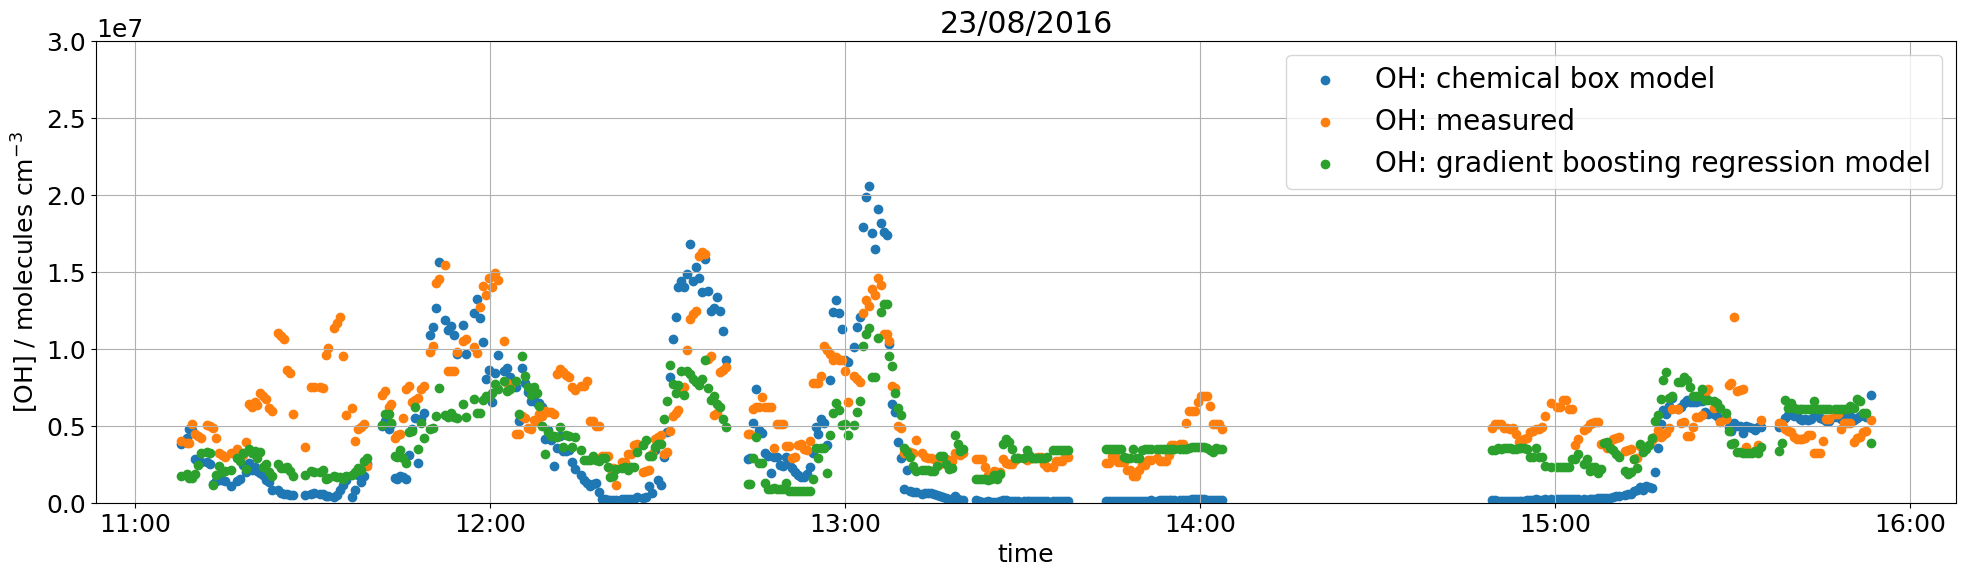

In [23]:
model = GradientBoostingRegressor(random_state=42)

model_HO2 = GradientBoostingRegressor(random_state=42)

model.fit(X_train_normalised, y_train)

model_HO2.fit(X_train_normalised_HO2, y_train)

y_pred = model.predict(X_test_normalised)

y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)

print(f"Model score on training data: {round(model.score(X_train_normalised, y_train), 3)}")
print(f"Model score on testing data: {round(model.score(X_test_normalised, y_test), 3)}")

print("===")
print("WITH HO2 IN FEATURES")

print(f"Model score on training data: {round(model_HO2.score(X_train_normalised_HO2, y_train), 3)}")
print(f"Model score on testing data: {round(model_HO2.score(X_test_normalised_HO2, y_test), 3)}")

mpl.rcParams["font.size"] = 18

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_pred[0:indexes], label="OH: gradient boosting regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("22/08/2016")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_pred[indexes:], label="OH: gradient boosting regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("23/08/2016")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


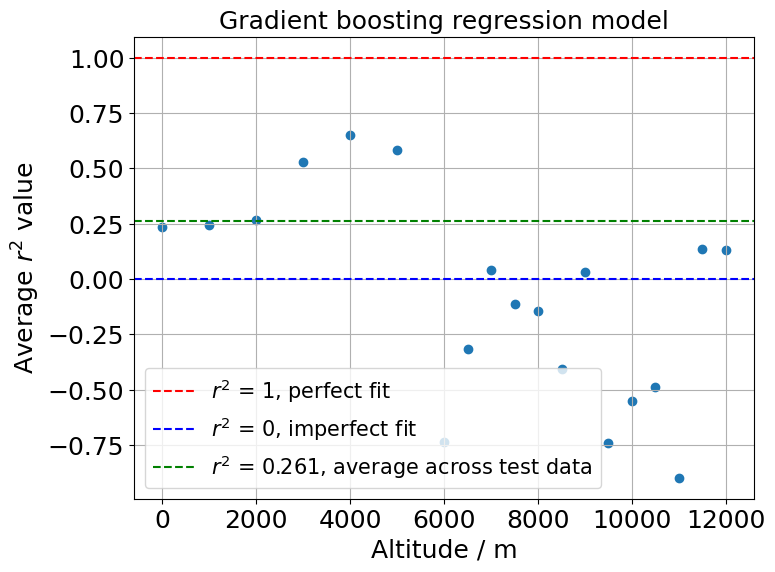

In [24]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    X = X_test_normalised[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(model.score(X, y))

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (model.score(X_test_normalised, y_test)), color='g', linestyle='--', label=f'$r^2$ = {round(model.score(X_test_normalised, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("Gradient boosting regression model")
plt.legend(prop={'size':15})

plt.grid()

In [25]:
print(f"RMSE: {sklearn.metrics.root_mean_squared_error(y_test, y_pred):.2e}")
print(f"RMSE with HO2: {sklearn.metrics.root_mean_squared_error(y_test, y_pred_HO2):.2e}")

RMSE: 2.40e+06
RMSE with HO2: 2.20e+06


Text(0.5, 1.0, 'Gradient boosting regression model')

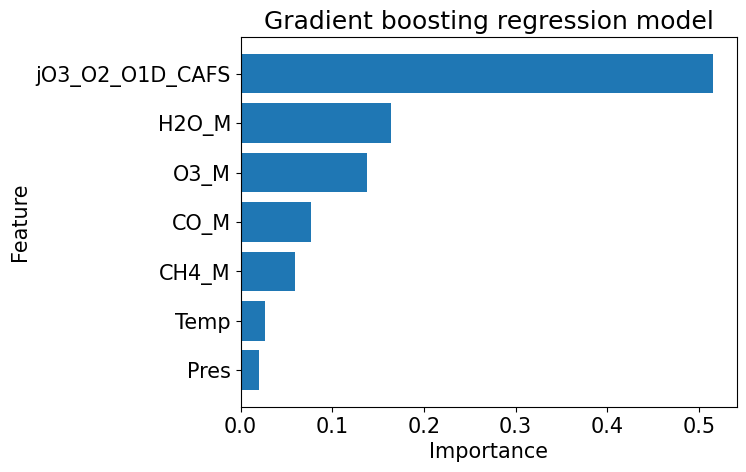

In [26]:
importances = model.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient boosting regression model")

Similar results as random forest feature importance

### Summary
From inspection of the plots above, the random forest and gradient boosting models fit the data and captured the altitude variance in $[OH]$ best. This is because they are ensemble methods and combined multiple individual models which improved accuracy compared to linear regression and ridge regression, which were single models. However, all four models struggled to capture the high variation in the measurements, particularly at large values of $[OH]$. 

While random forest and gradient boosting had the best performance on the training data, shown by the scores of 0.980 and 0.824 on the training data respectively, all models showed signs of overfitting because the $r^2$ scores were lower (less than 0.35) on the testing data, compared to the training data which had $r^2$ scores in the range of 0.4 to 1. This significantly poorer performance on test data suggested the unsuitability of a timeseries split, as the ATom aircraft was non-stationary. The aircraft was in different areas of the troposphere on different dates, causing changes in physical variables such as latitude and longitude. Therefore, it is likely that the data from the training dates would not have been fully representative of the last 2 dates, resulting in a poor $r^2$ score.